In [1]:
from platform import python_version
print(python_version())

3.11.14


### Calculating DEGs statistics

### For each LFC/FDR cutoff set, we get a different set of DEGs
  - LFC: LFC cutoff and FDR_LFC cutoff
  - Pathway: fdr and pval pathway cutoff and min num of genes

### Up and Down DEGs simulation
  - Up and Down DEGs/DAPs
  - Up and Down in pathways

### there are 2 statistical tables
  - pval/fdr cutoff x degs
  - pval/fdr/geneset/quantile degs_in_pathway, num_pathways

In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.tcga_gdc_lib import GDC
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"


PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
s_omics

'RNA-Seq'

In [5]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

Start opening tables ....
Building synonym dictionary ...

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC
>>> Tumor
>>> case Tumor
	DEGs 20006
		Up (#10358)
		Dw (#9648)

Up-regulated per biotype
                               biotype     n
0                            IG_C_gene    12
1                      IG_C_pseudogene     4
2                            IG_D_gene     1
3                            IG_J_gene     9
4                      IG_J_pseudogene     1
5                            IG_V_gene   124
6                      IG_V_pseudogene    50
7                              Mt_tRNA    17
8                                  TEC   112
9                            TR_C_gene     5
10                           TR_D_gene     1
11                           TR_J_gene    10
12                           TR_V_gene    69
13                     TR_V_pseudogene     1
14                              lncRNA  3193
15                               miRNA   

In [6]:
gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA)

### Get all programs

In [7]:
force = False
verbose = True

prog_list = gdc.get_gdc_progams(force=force, verbose=verbose)

df_psi = gdc.get_primary_sites(prog_id=PROG_ID, force=False, verbose=verbose)
print(len(df_psi))

df_psi.shape, df_psi.columns

File read at '/home/flavio/uv/perturb_agent/data/gdc_programs.txt'
Table opened ((33, 5)) at '/home/flavio/uv/perturb_agent/data/TCGA/primary_site_program_TCGA.tsv'
33


((33, 5),
 Index(['psi_id', 'primary_site', 'project_id', 'disease_type', 'name'], dtype='object'))

In [8]:
gdc.set_primary_site(psi_id=PSI_ID, verbose=True)


-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC
>> root samples: /home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC/mutations
-----------------------------



True

In [9]:
verbose=False
df_tumor, df_normal, df_gtex_ctrl = gdc.get_file_expression_both_tumor_and_normal(verbose=verbose)

Dowloading normal files: 0.
Dowloading tumor files: 0..........10..........20..........30..........40..........50..........60..........70..........80..........90..........100..........110..........120..........130..........140..........150..........160..........170..........180..........190..........200....
Preparing GTEx metadata...
GTEx metadata prepared on df_meta_prep length: 7


In [10]:
# gdc.df_meta["SMTSD"].unique()

In [11]:
print(len(df_tumor.columns)-3)
df_tumor.head(3)

12


,geneid,symbol,biotype,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,tumor_9,tumor_10,tumor_11,tumor_12
0,ENSG00000000003,TSPAN6,protein_coding,2121,2582,218,1639,1087,544,788,1893,1198,816,1601,3864
1,ENSG00000000005,TNMD,protein_coding,1,0,0,1,0,0,2,1,0,0,35,1
2,ENSG00000000419,DPM1,protein_coding,1263,1301,327,1167,1123,686,1289,1446,1505,1744,1247,1299


In [12]:
print(len(df_normal.columns)-3)
df_normal.head(3)

1


,geneid,symbol,biotype,normal_1
0,ENSG00000000003,TSPAN6,protein_coding,1664
1,ENSG00000000005,TNMD,protein_coding,15
2,ENSG00000000419,DPM1,protein_coding,1274


In [13]:
print(len(df_gtex_ctrl.columns)-2)
df_gtex_ctrl.head(3)

3


,ensemblid,symbol,GTEX-SN8G-2126-SM-GPI8G,GTEX-T2IS-2326-SM-HL9TW,GTEX-Q2AG-2326-SM-EZ6KY
0,ENSG00000290825.2,DDX11L16,0,0,1
1,ENSG00000223972.6,DDX11L1,0,0,0
2,ENSG00000310526.1,WASH7P,433,373,515


### CALC_DEGS -> build_counts_and_metadata()

In [14]:
cdegs = CALC_DEGS(root_src=gdc.root_src, run_conda=False)
gdc.cdegs = cdegs

verbose=True
df_tumor, df_normal, msg = gdc.get_tumor_normal_tables(verbose=verbose)

Table opened ((307, 23)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC/cases_for_TCGA-CESC.tsv'
Table opened ((4544, 14)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC/samples/samples_for_TCGA-CESC_Cervix_uteri_Ovary_subtype_squamous_tumor_squamous_cell_carcinoma_subtype_tissue_squamous.tsv'
Table opened ((3813, 26)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC/mutations/mutations_anal_for_study_TCGA-CESC_Cervix_uteri_Ovary_subtype_squamous_tumor_squamous_cell_carcinoma_subtype_tissue_squamous.tsv'
Table opened ((4013, 14)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC/samples/samples_for_TCGA-CESC_Cervix_uteri_Ovary_subtype_adenocarcinoma_generic_tumor_adenocarcinoma_subtype_tissue_adenocarcinoma_generic.tsv'
Table opened ((4718, 26)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-CESC/mutations/mutations_anal_for_study_TCGA-CESC_Cervix_uteri_Ovary_subtype_adenocarcinoma_generic_tumor_adenocarcinoma_subtype_tissue_adenocarcinoma_generic.tsv'
Table op

In [15]:
df_tumor.head(3)

,geneid,symbol,biotype,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,tumor_9,tumor_10,tumor_11,tumor_12
0,ENSG00000000003,TSPAN6,protein_coding,2121,2582,218,1639,1087,544,788,1893,1198,816,1601,3864
1,ENSG00000000005,TNMD,protein_coding,1,0,0,1,0,0,2,1,0,0,35,1
2,ENSG00000000419,DPM1,protein_coding,1263,1301,327,1167,1123,686,1289,1446,1505,1744,1247,1299


In [16]:
df_normal.head(3)

,geneid,symbol,biotype,normal_1,normal_2,normal_3
0,ENSG00000000003,TSPAN6,protein_coding,1846,2305,3292
1,ENSG00000000005,TNMD,protein_coding,8,4,11
2,ENSG00000000419,DPM1,protein_coding,826,1251,1344


In [17]:
df_counts, df_meta = cdegs.build_counts_and_metadata(
            df_tumor=df_tumor,
            df_normal=df_normal,
            how="inner"
        )

df_counts.head(3)

,geneid,normal_1,normal_2,normal_3,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,tumor_9,tumor_10,tumor_11,tumor_12
0,ENSG00000000003,1846,2305,3292,2121,2582,218,1639,1087,544,788,1893,1198,816,1601,3864
1,ENSG00000000005,8,4,11,1,0,0,1,0,0,2,1,0,0,35,1
2,ENSG00000000419,826,1251,1344,1263,1301,327,1167,1123,686,1289,1446,1505,1744,1247,1299


In [18]:
df_meta

,sample,condition
0,normal_1,normal
1,normal_2,normal
2,normal_3,normal
3,tumor_1,tumor
4,tumor_2,tumor
5,tumor_3,tumor
6,tumor_4,tumor
7,tumor_5,tumor
8,tumor_6,tumor
9,tumor_7,tumor


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

def build_df_exp_and_filter(
    df_counts: pd.DataFrame,
    df_meta: pd.DataFrame,
    gene_col: str = "geneid",
    condition_col: str = "condition",
    sample_col: str = "sample",
    tumor_label: str = "tumor",
    normal_label: str = "normal",
    equal_var: bool = False,   # False = Welch t-test, safer when n differs
) -> tuple[pd.DataFrame, list, list]:
    df = df_counts.copy()

    # Samples by condition
    normal_samples = df_meta.loc[
        df_meta[condition_col] == normal_label, sample_col
    ].tolist()

    tumor_samples = df_meta.loc[
        df_meta[condition_col] == tumor_label, sample_col
    ].tolist()

    # Keep only samples present in df_counts
    normal_samples = [s for s in normal_samples if s in df.columns]
    tumor_samples = [s for s in tumor_samples if s in df.columns]

    sample_cols = normal_samples + tumor_samples

    ncols_normal = len(normal_samples)
    ncols_tumor  = len(tumor_samples)

    nmin_cols = min(ncols_normal, ncols_tumor)

    df["total"] = df[sample_cols].sum(axis=1)

    df = df.loc[
        df["total"] > nmin_cols * 25
    ].reset_index(drop=True, inplace=False)



    # Convert counts to numeric
    df[normal_samples + tumor_samples] = df[normal_samples + tumor_samples].apply(
        pd.to_numeric, errors="coerce"
    )

    # Optional but recommended for RNA-seq counts:
    # log-transform before t-test
    normal_mat = np.log2(df[normal_samples] + 1)
    tumor_mat = np.log2(df[tumor_samples] + 1)

    # Row-wise t-test: tumor vs normal
    t_stat, pval = ttest_ind(
        tumor_mat,
        normal_mat,
        axis=1,
        equal_var=equal_var,
        nan_policy="omit",
    )

    df["t_stat"] = t_stat
    df["pval"] = pval

    # Useful summaries
    df["mean_normal"] = normal_mat.mean(axis=1)
    df["mean_tumor"] = tumor_mat.mean(axis=1)
    df["lfc"] = df["mean_tumor"] - df["mean_normal"]
    df["abs_lfc"] = df["lfc"].abs()

    # Order by p-value
    df = df.sort_values("pval", ascending=True)

    # Keep the 40% lowest p-values
    df = df[df.lfc < 0.01]
    df.reset_index(drop=True, inplace=True)

    return df, normal_samples, tumor_samples


In [ ]:
dff, normal_samples, tumor_samples = build_df_exp_and_filter(df_counts=df_counts, df_meta=df_meta,
    gene_col = "geneid",
    equal_var = False,)   # False = Welch t-test, safer when n differs

print(len(df_counts), len(dff))

dff.head(3)

55751 17833


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


,geneid,normal_1,normal_2,normal_3,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,...,tumor_10,tumor_11,tumor_12,total,t_stat,pval,mean_normal,mean_tumor,lfc,abs_lfc
0,ENSG00000187664,159,163,146,0,1,0,0,0,0,...,0,0,0,470,-58.358,4.054e-17,7.293,0.167,-7.126,7.126
1,ENSG00000267206,126,132,133,0,0,0,0,0,0,...,0,0,0,393,-59.769,4.009e-16,7.037,0.167,-6.870,6.870
2,ENSG00000225156,36,40,36,0,0,0,0,0,0,...,0,1,0,113,-53.434,1.305e-15,5.259,0.083,-5.175,5.175


In [37]:
import seaborn as sns

In [56]:
cols = ['geneid'] + normal_samples + tumor_samples

dff2 = dff[cols].copy()
dff2.set_index('geneid', inplace=True)
dff2.head(3)

,normal_1,normal_2,normal_3,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,tumor_9,tumor_10,tumor_11,tumor_12
geneid,,,,,,,,,,,,,,,
ENSG00000187664,159,163,146,0,1,0,0,0,0,0,0,1,0,0,0
ENSG00000267206,126,132,133,0,0,0,0,0,0,1,0,1,0,0,0
ENSG00000225156,36,40,36,0,0,0,0,0,0,0,0,0,0,1,0


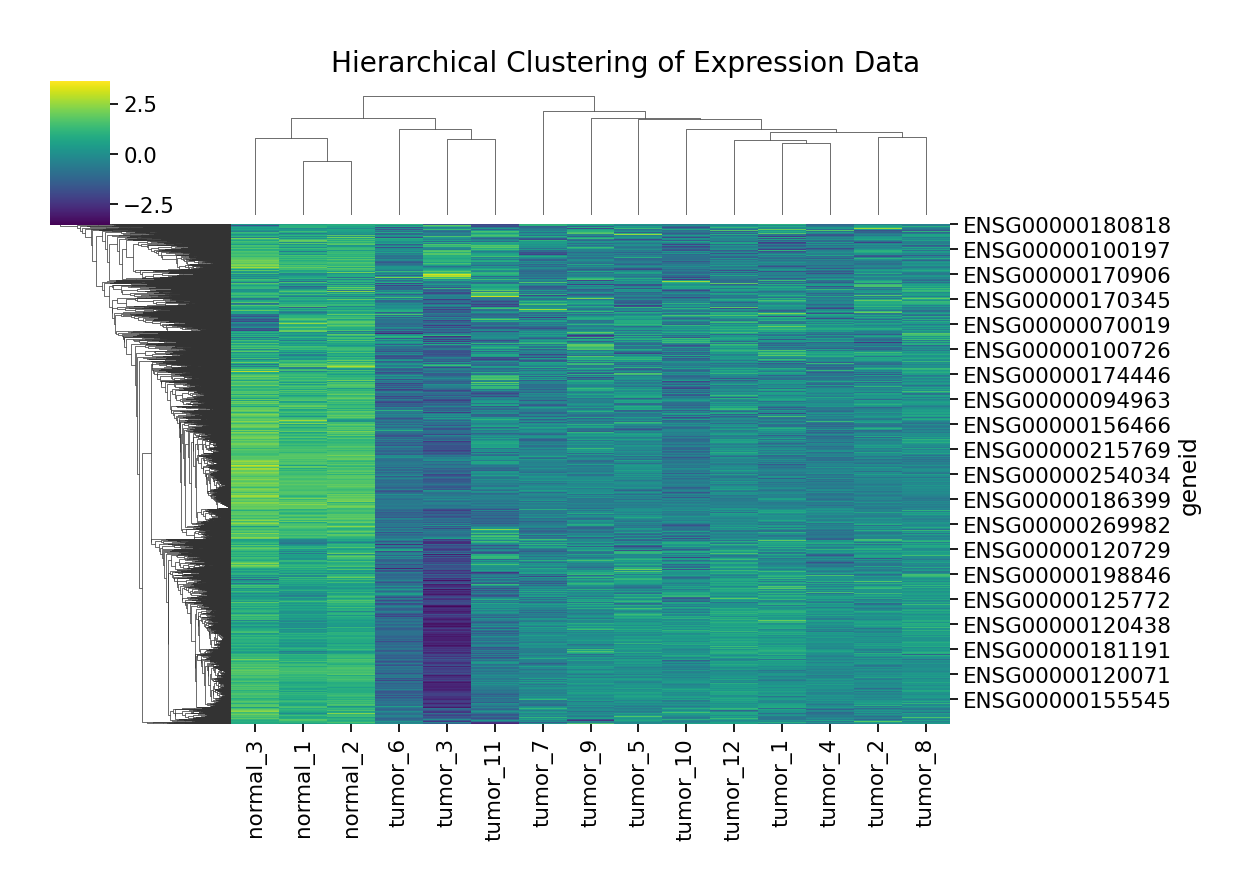

In [57]:
import matplotlib.pyplot as plt
from scipy.stats import zscore

figsize = (12,8)

title = 'Hierarchical Clustering of Expression Data'

# numeric matrix
dff2 = dff2.apply(pd.to_numeric, errors="coerce").fillna(0)
mat = np.log2(dff2 + 1)

# gene-wise z-score using pandas/numpy
row_mean = mat.mean(axis=1)
row_std = mat.std(axis=1)

mat_z = mat.sub(row_mean, axis=0).div(row_std.replace(0, np.nan), axis=0)
mat_z = mat_z.replace([np.inf, -np.inf], np.nan).fillna(0)

cg = sns.clustermap(
    mat_z,
    metric="correlation",
    method="average",
    figsize=figsize,
    cmap="viridis",
    cbar=True,
)

title = "Hierarchical Clustering of Expression Data"
cg.figure.suptitle(title, y=1.02)

plt.show()


In [58]:
mat_z

,normal_1,normal_2,normal_3,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,tumor_9,tumor_10,tumor_11,tumor_12
geneid,,,,,,,,,,,,,,,
ENSG00000187664,1.929,1.941,1.888,-0.536,-0.199,-0.536,-0.536,-0.536,-0.536,-0.536,-0.536,-0.199,-0.536,-0.536,-0.536
ENSG00000267206,1.901,1.925,1.928,-0.538,-0.538,-0.538,-0.538,-0.538,-0.538,-0.189,-0.538,-0.189,-0.538,-0.538,-0.538
ENSG00000225156,1.895,1.964,1.895,-0.518,-0.518,-0.518,-0.518,-0.518,-0.518,-0.518,-0.518,-0.518,-0.518,-0.055,-0.518
ENSG00000188004,1.919,1.914,1.921,-0.555,-0.255,-0.555,-0.555,-0.255,-0.555,-0.255,-0.555,-0.555,-0.555,-0.555,-0.555
ENSG00000100359,1.923,1.930,1.869,-0.643,-0.469,-0.088,-0.565,-0.565,-0.515,-0.442,-0.515,-0.296,-0.713,-0.268,-0.643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000246705,-0.204,-0.306,0.511,0.600,-0.044,1.689,0.141,-2.272,0.325,-1.823,1.305,0.185,-0.012,-0.185,0.089
ENSG00000125656,-0.615,0.287,0.327,-0.148,2.003,1.211,-1.318,-0.301,-0.193,-2.108,1.121,-0.488,0.248,0.168,-0.193
ENSG00000121552,0.969,0.962,-1.929,0.788,0.621,-1.500,0.639,-0.038,-0.539,-0.081,0.866,-0.125,0.126,-1.680,0.920
